# License Plate Detection and Recovery

Add the dataset as a Kaggle input, turn on Internet in notebook settings, then run all cells. It imports the data and trains itself.

In [1]:
import subprocess, sys, shutil

def install(pkgs):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q"] + pkgs, check=False)

install(["opencv-python-headless>=4.8,<5", "pytesseract", "pandas", "scikit-learn",
          "matplotlib", "pyyaml", "tqdm", "ultralytics"])

if shutil.which("tesseract") is None:
    subprocess.run(["apt-get", "-qq", "update"], check=False)
    subprocess.run(["apt-get", "-qq", "install", "-y", "tesseract-ocr"], check=False)

print("tesseract:", shutil.which("tesseract"))

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.4/46.4 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.4/75.4 kB 6.1 MB/s eta 0:00:00
tesseract: /usr/bin/tesseract


In [2]:
import os, re, glob, json, random, shutil, zipfile
import xml.etree.ElementTree as ET
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import cv2
import pytesseract
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# figure out where we are running: kaggle, colab, or local
ON_KAGGLE = os.path.isdir("/kaggle/input")
ON_COLAB = os.path.isdir("/content") and not ON_KAGGLE
INPUT_DIR = "/kaggle/input" if ON_KAGGLE else ("/content" if ON_COLAB else os.getcwd())
WORK_DIR = "/kaggle/working" if ON_KAGGLE else ("/content" if ON_COLAB else os.getcwd())

MODEL_DIR = os.path.join(WORK_DIR, "models")
YOLO_DIR = os.path.join(WORK_DIR, "yolo_data")
OUT_DIR = os.path.join(WORK_DIR, "outputs")
for d in [MODEL_DIR, YOLO_DIR, OUT_DIR, os.path.join(OUT_DIR, "samples")]:
    os.makedirs(d, exist_ok=True)

EPOCHS = 40
IMG_SIZE = 640
PLATE_SIZE = (256, 96)   # width, height after rectify

print("running on:", "kaggle" if ON_KAGGLE else "colab" if ON_COLAB else "local")
print("input dir:", INPUT_DIR)
print("work dir:", WORK_DIR)

running on: kaggle
input dir: /kaggle/input
work dir: /kaggle/working


Locate the dataset under /kaggle/input, or unzip it if it was uploaded as a zip.

In [3]:
def find_dataset(input_dir):
    best, best_n = None, 0
    if os.path.isdir(input_dir):
        for name in sorted(os.listdir(input_dir)):
            path = os.path.join(input_dir, name)
            if not os.path.isdir(path):
                continue
            n = len(glob.glob(os.path.join(path, "**", "*.xml"), recursive=True))
            if n > best_n:
                best, best_n = path, n
    return best, best_n

DATA_DIR, n_found = find_dataset(INPUT_DIR)

if DATA_DIR is None:
    zips = glob.glob(os.path.join(INPUT_DIR, "**", "*.zip"), recursive=True) + \
           glob.glob(os.path.join(WORK_DIR, "*.zip"))
    if not zips:
        raise FileNotFoundError("No dataset found. Add it as a Kaggle input or upload dataset.zip.")
    DATA_DIR = os.path.join(WORK_DIR, "dataset_extracted")
    os.makedirs(DATA_DIR, exist_ok=True)
    with zipfile.ZipFile(zips[0]) as zf:
        zf.extractall(DATA_DIR)
    entries = [e for e in os.listdir(DATA_DIR) if not e.startswith("__MACOSX")]
    if len(entries) == 1 and os.path.isdir(os.path.join(DATA_DIR, entries[0])):
        DATA_DIR = os.path.join(DATA_DIR, entries[0])
    n_found = len(glob.glob(os.path.join(DATA_DIR, "**", "*.xml"), recursive=True))

print("dataset:", DATA_DIR)
print("xml files found:", n_found)
print("folders:", os.listdir(DATA_DIR))

dataset: /kaggle/input/datasets
xml files found: 1697
folders: ['saisirishan']


Parse the xml annotations. Each one gives a bounding box and the plate text in the same file.

In [4]:
SKIP_LABELS = {"blur", "devanagri", "devnagari", "unreadable", "illegible", "na", "n/a", "unknown"}

def load_annotations(root_dir):
    rows = []
    for xml_path in glob.glob(os.path.join(root_dir, "**", "*.xml"), recursive=True):
        try:
            root = ET.parse(xml_path).getroot()
        except ET.ParseError:
            continue
        folder = os.path.dirname(xml_path)
        filename = root.findtext("filename")
        text = root.findtext("object/name")
        box = root.find("object/bndbox")
        if filename is None or text is None or box is None:
            continue
        text = text.strip()
        if text.lower() in SKIP_LABELS or not re.search(r"[A-Za-z0-9]", text):
            continue
        img_path = os.path.join(folder, filename)
        if not os.path.isfile(img_path):
            stem = os.path.splitext(filename)[0]
            for ext in (".jpg", ".jpeg", ".png"):
                if os.path.isfile(os.path.join(folder, stem + ext)):
                    img_path = os.path.join(folder, stem + ext)
                    break
            else:
                continue
        try:
            xmin, ymin = int(float(box.findtext("xmin"))), int(float(box.findtext("ymin")))
            xmax, ymax = int(float(box.findtext("xmax"))), int(float(box.findtext("ymax")))
        except (TypeError, ValueError):
            continue
        if xmax <= xmin or ymax <= ymin:
            continue
        rows.append({"image_path": img_path, "plate_text": text.upper(),
                      "xmin": xmin, "ymin": ymin, "xmax": xmax, "ymax": ymax})
    return pd.DataFrame(rows)

df = load_annotations(DATA_DIR)
print("records:", len(df))
print("unique plates:", df["plate_text"].nunique())
counts = df["plate_text"].value_counts()
print("plates with 2 or more photos:", (counts >= 2).sum())
print(counts.head(10))

records: 1693
unique plates: 980
plates with 2 or more photos: 219
plate_text
MH02BT6482    41
MH47Y1124     41
MH02DS9365    34
MH03CS6266    27
MH02BQ9628    20
MH02ER9194    19
RJ27TC0530    18
MH4705851     17
MH01AU0059    17
MH03BS4060    16
Name: count, dtype: int64


Split train and val by plate text, and group plates that have more than one photo.

In [5]:
plates = sorted(df["plate_text"].unique())
rng = random.Random(SEED)
rng.shuffle(plates)
n_val = max(1, int(0.15 * len(plates)))
val_plates = set(plates[:n_val])
df["split"] = df["plate_text"].apply(lambda t: "val" if t in val_plates else "train")

def make_groups(frame):
    groups = defaultdict(list)
    for _, row in frame.iterrows():
        groups[row["plate_text"]].append(row.to_dict())
    return {k: v for k, v in groups.items() if len(v) >= 2}

train_groups = make_groups(df[df["split"] == "train"])
val_groups = make_groups(df[df["split"] == "val"])
val_groups_3plus = {k: v for k, v in val_groups.items() if len(v) >= 3}

print(df["split"].value_counts())
print("train groups (2+ photos):", len(train_groups))
print("val groups (2+ photos):", len(val_groups), "| val groups (3+ photos):", len(val_groups_3plus))

split
train    1448
val       245
Name: count, dtype: int64
train groups (2+ photos): 183
val groups (2+ photos): 36 | val groups (3+ photos): 15


Train a YOLOv8n detector on the plate boxes.

In [6]:
def to_yolo_format(frame, out_dir):
    if os.path.exists(out_dir):
        shutil.rmtree(out_dir)
    for split in ("train", "val"):
        os.makedirs(os.path.join(out_dir, "images", split), exist_ok=True)
        os.makedirs(os.path.join(out_dir, "labels", split), exist_ok=True)

    for i, row in frame.reset_index(drop=True).iterrows():
        img = cv2.imread(row["image_path"])
        if img is None:
            continue
        h, w = img.shape[:2]
        xmin = max(0, min(row["xmin"], w)); xmax = max(0, min(row["xmax"], w))
        ymin = max(0, min(row["ymin"], h)); ymax = max(0, min(row["ymax"], h))
        if xmax <= xmin or ymax <= ymin:
            continue
        cx, cy = (xmin + xmax) / 2 / w, (ymin + ymax) / 2 / h
        bw, bh = (xmax - xmin) / w, (ymax - ymin) / h
        split = row["split"]
        stem = f"{i:06d}"
        cv2.imwrite(os.path.join(out_dir, "images", split, stem + ".jpg"), img)
        with open(os.path.join(out_dir, "labels", split, stem + ".txt"), "w") as f:
            f.write(f"0 {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}\n")

    import yaml
    yaml_path = os.path.join(out_dir, "data.yaml")
    yaml.dump({"path": out_dir, "train": "images/train", "val": "images/val", "names": {0: "plate"}},
               open(yaml_path, "w"))
    return yaml_path

data_yaml = to_yolo_format(df, YOLO_DIR)
print("train images:", len(os.listdir(os.path.join(YOLO_DIR, "images", "train"))))
print("val images:", len(os.listdir(os.path.join(YOLO_DIR, "images", "val"))))

train images: 1448
val images: 245


In [7]:
detector = None
detector_path = os.path.join(MODEL_DIR, "plate_detector.pt")

try:
    from ultralytics import YOLO
    import torch
    device = 0 if torch.cuda.is_available() else "cpu"
    print("training on", device, "for", EPOCHS, "epochs")

    base = YOLO("yolov8n.pt")
    base.train(data=data_yaml, epochs=EPOCHS, imgsz=IMG_SIZE, device=device,
               verbose=False, plots=False, patience=15,
               project=os.path.join(WORK_DIR, "runs"), name="plate_detector", exist_ok=True)

    best = os.path.join(WORK_DIR, "runs", "plate_detector", "weights", "best.pt")
    if os.path.isfile(best):
        shutil.copy(best, detector_path)
        detector = YOLO(detector_path)
        metrics = detector.val(data=data_yaml, verbose=False)
        print("saved trained detector to", detector_path)
        print(f"detector mAP50={metrics.box.map50:.3f} precision={metrics.box.mp:.3f} recall={metrics.box.mr:.3f}")
except Exception as e:
    print("detector training failed or unavailable:", e)
    print("falling back to a classical detector below")

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
training on 0 for 40 epochs
Ultralytics 8.4.146 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/yolo_data/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=40, erasing=0.4, exist_ok=True, fliplr=

/usr/local/lib/python3.12/dist-packages/ray/train/_internal/session.py:676: UserWarning: `get_trial_id` is meant to only be called inside a function that is executed by a Tuner or Trainer. Returning `None`.
  warnings.warn(


       2/40      2.56G     0.9493      1.095     0.9735         14        640: 100% ━━━━━━━━━━━━ 91/91 7.2it/s 12.6s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 5.3it/s 1.5s
                   all        245        245      0.926      0.882      0.952      0.665

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       3/40      2.56G     0.9323     0.8751     0.9816         15        640: 100% ━━━━━━━━━━━━ 91/91 6.9it/s 13.2s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 5.6it/s 1.4s
                   all        245        245      0.914      0.837      0.929      0.635

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       4/40      2.56G     0.9332     0.7583     0.9927         18        640: 100% ━━━━━━━━━━━━ 91/91 7.2it/s 12.7s
                 Class     Images  Instances      Box(P        

In [8]:
# fallback chain: trained yolo model, then haar cascade, then a simple contour search
# this way the pipeline never fails to give a crop even without a trained model
haar_path = os.path.join(getattr(cv2.data, "haarcascades", ""), "haarcascade_russian_plate_number.xml")
haar = None
if os.path.isfile(haar_path) and hasattr(cv2, "CascadeClassifier"):
    c = cv2.CascadeClassifier(haar_path)
    if not c.empty():
        haar = c

def contour_guess(bgr):
    h, w = bgr.shape[:2]
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
    edges = cv2.dilate(cv2.Canny(gray, 50, 150), np.ones((3, 3), np.uint8))
    contours, _ = cv2.findContours(edges, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)
    best, best_area = None, -1
    for c in contours:
        x, y, cw, ch = cv2.boundingRect(c)
        if cw < 20 or ch < 8 or not (1.5 <= cw / ch <= 8.0):
            continue
        if cw * ch > best_area:
            best_area, best = cw * ch, (x, y, x + cw, y + ch)
    return best if best else (int(w * 0.2), int(h * 0.55), int(w * 0.8), int(h * 0.85))

def detect_plate(bgr, gt_box=None):
    if gt_box is not None:
        return (*gt_box, "gt")
    if detector is not None:
        try:
            res = detector.predict(bgr, verbose=False, conf=0.25)[0]
            if len(res.boxes) > 0:
                idx = int(res.boxes.conf.argmax())
                x1, y1, x2, y2 = [int(v) for v in res.boxes.xyxy[idx].tolist()]
                return (x1, y1, x2, y2, "yolo")
        except Exception:
            pass
    if haar is not None:
        boxes = haar.detectMultiScale(cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY), 1.1, 4)
        if len(boxes) > 0:
            x, y, w, h = max(boxes, key=lambda b: b[2] * b[3])
            return (x, y, x + w, y + h, "haar")
    x1, y1, x2, y2 = contour_guess(bgr)
    return (x1, y1, x2, y2, "contour")

print("detector ready. yolo trained:", detector is not None, "| haar available:", haar is not None)

detector ready. yolo trained: True | haar available: True


Score crop quality, rectify to a fixed size, then clean up only what actually needs it.

In [9]:
WEIGHTS = {"blur": 0.30, "exposure": 0.15, "noise": 0.15, "resolution": 0.20,
           "perspective": 0.10, "occlusion": 0.10}

def check_quality(gray_u8):
    h, w = gray_u8.shape
    gray = gray_u8.astype(np.float32)

    blur = float(np.clip(cv2.Laplacian(gray_u8, cv2.CV_64F).var() / 500.0, 0, 1))

    mean_i = gray.mean()
    clipped = float(np.mean((gray < 5) | (gray > 250)))
    exposure = float(np.clip((1.0 - abs(mean_i - 127.5) / 127.5) * (1.0 - clipped), 0, 1))

    median = cv2.medianBlur(gray_u8, 3).astype(np.float32)
    noise = float(np.clip(1.0 - np.std(gray - median) / 25.0, 0, 1))

    resolution = float(np.clip(w / 140.0, 0, 1))

    aspect = w / max(h, 1)
    perspective = float(np.clip(1.0 - abs(aspect - 4.5) / 4.5, 0, 1))

    row_std = gray.std(axis=1)
    occlusion = float(np.clip(1.0 - np.mean(row_std < 5.0), 0, 1))

    scores = {"blur": blur, "exposure": exposure, "noise": noise,
              "resolution": resolution, "perspective": perspective, "occlusion": occlusion}
    log_sum = sum(WEIGHTS[k] * np.log(max(scores[k], 1e-3)) for k in scores)
    scores["combined"] = float(np.exp(log_sum))
    return scores


def rectify(crop, size=PLATE_SIZE):
    h, w = crop.shape[:2]
    if h == 0 or w == 0:
        return np.zeros((size[1], size[0], 3), np.uint8)
    src = np.float32([[0, 0], [w, 0], [w, h], [0, h]])
    cw, ch = size
    dst = np.float32([[0, 0], [cw, 0], [cw, ch], [0, ch]])
    M = cv2.getPerspectiveTransform(src, dst)
    return cv2.warpPerspective(crop, M, size)


def clean_up(bgr, quality):
    out = bgr.copy()
    if quality["noise"] < 0.6:
        out = cv2.fastNlMeansDenoisingColored(out, None, 7, 7, 7, 21)
    if quality["exposure"] < 0.6:
        lab = cv2.cvtColor(out, cv2.COLOR_BGR2LAB)
        l, a, b = cv2.split(lab)
        l = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(8, 8)).apply(l)
        out = cv2.cvtColor(cv2.merge([l, a, b]), cv2.COLOR_LAB2BGR)
    if quality["blur"] < 0.6:
        blurred = cv2.GaussianBlur(out, (0, 0), 2.0)
        out = cv2.addWeighted(out, 1.6, blurred, -0.6, 0)
    if quality["resolution"] < 0.6:
        out = cv2.resize(out, None, fx=2.0, fy=2.0, interpolation=cv2.INTER_CUBIC)
        out = cv2.detailEnhance(out, sigma_s=10, sigma_r=0.15)
    return out

print("quality check and cleanup ready")

quality check and cleanup ready


Read the plate text with tesseract, with a small confidence floor for later voting.

In [10]:
CHARS = "ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789"

def read_plate(bgr):
    gray = cv2.resize(cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY), None, fx=2.0, fy=2.0,
                       interpolation=cv2.INTER_CUBIC)
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    config = f"--psm 7 -c tessedit_char_whitelist={CHARS}"
    text = re.sub(r"[^A-Z0-9]", "", pytesseract.image_to_string(thresh, config=config).upper())
    try:
        data = pytesseract.image_to_data(thresh, config=config, output_type=pytesseract.Output.DICT)
        confs = [float(c) for c in data["conf"] if c not in ("-1", -1)]
        conf = (sum(confs) / len(confs) / 100.0) if confs else 0.3
    except Exception:
        conf = 0.3
    conf = max(conf, 0.15)
    return text, conf

print("ocr ready")

ocr ready


Combine readings from multiple photos of the same plate letter by letter, instead of just picking one photo.

In [11]:
SIMILAR = {"O": ["0"], "0": ["O"], "I": ["1"], "1": ["I"], "B": ["8"], "8": ["B"],
           "S": ["5"], "5": ["S"], "Z": ["2"], "2": ["Z"], "G": ["6"], "6": ["G"]}

def align(ref, seq, gap=-1, match=2, mismatch=-1):
    n, m = len(ref), len(seq)
    dp = np.zeros((n + 1, m + 1))
    for i in range(n + 1):
        dp[i][0] = i * gap
    for j in range(m + 1):
        dp[0][j] = j * gap
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            s = match if ref[i - 1] == seq[j - 1] else mismatch
            dp[i][j] = max(dp[i-1][j-1] + s, dp[i-1][j] + gap, dp[i][j-1] + gap)
    i, j, pairs = n, m, []
    while i > 0 or j > 0:
        if i > 0 and j > 0:
            s = match if ref[i-1] == seq[j-1] else mismatch
            if dp[i][j] == dp[i-1][j-1] + s:
                pairs.append((i - 1, seq[j - 1])); i -= 1; j -= 1; continue
        if i > 0 and dp[i][j] == dp[i-1][j] + gap:
            i -= 1; continue
        j -= 1
    return list(reversed(pairs))


def combine_readings(readings, credit=0.4):
    # readings: list of dict with text, conf, weight
    readings = [r for r in readings if r["text"]]
    if not readings:
        return "", []
    ref_len = int(np.median([len(r["text"]) for r in readings]))
    same_len = [r["text"] for r in readings if len(r["text"]) == ref_len]
    ref = same_len[0] if same_len else max(readings, key=lambda r: len(r["text"]))["text"]

    votes = [dict() for _ in range(len(ref))]
    for r in readings:
        for pos, ch in align(ref, r["text"]):
            if pos < len(votes):
                votes[pos][ch] = votes[pos].get(ch, 0.0) + r["weight"] * r["conf"]

    # give partial credit to similar looking characters, but only where
    # both characters already have their own direct votes at this spot
    for pos_votes in votes:
        if len(pos_votes) < 2:
            continue
        snapshot = dict(pos_votes)
        extra = {}
        for ch, w in snapshot.items():
            for alt in SIMILAR.get(ch, []):
                if alt in snapshot and alt != ch:
                    extra[alt] = extra.get(alt, 0.0) + w * credit
        for alt, w in extra.items():
            pos_votes[alt] = pos_votes.get(alt, 0.0) + w

    out_text, out_conf = [], []
    for pos_votes in votes:
        if not pos_votes:
            out_text.append("?"); out_conf.append(0.0); continue
        total = sum(pos_votes.values())
        best_ch, best_w = max(pos_votes.items(), key=lambda kv: kv[1])
        c = best_w / total if total else 0.0
        out_text.append(best_ch if c >= 0.35 else "?")
        out_conf.append(c)
    return "".join(out_text), out_conf


def reweight(readings, fused_text):
    out = []
    for r in readings:
        n = min(len(r["text"]), len(fused_text))
        agree = (sum(a == b for a, b in zip(r["text"][:n], fused_text[:n])) / n) if n else 0.0
        out.append({**r, "weight": r["weight"] * max(0.2, agree)})
    return out


def fuse_group(readings):
    first, _ = combine_readings(readings)
    return combine_readings(reweight(readings, first))

print("character combining ready")

character combining ready


In [12]:
def confidence_score(ocr_conf, agreement, stability, quality, geometry):
    weights = {"ocr": 0.30, "agreement": 0.20, "stability": 0.20, "quality": 0.15, "geometry": 0.15}
    parts = {"ocr": ocr_conf, "agreement": agreement, "stability": stability,
             "quality": quality, "geometry": geometry}
    score = sum(weights[k] * parts[k] for k in weights)
    return float(np.clip(score, 0, 1))


def final_text(text, char_conf, score, char_thresh=0.35, score_thresh=0.25):
    if score < score_thresh or not text:
        return None, "unreadable"
    return "".join(c if cc >= char_thresh else "?" for c, cc in zip(text, char_conf)), "ok"


def char_accuracy(pred, gt):
    if not gt:
        return 0.0
    L = max(len(pred), len(gt))
    pred = pred.ljust(L, "\0"); gt2 = gt.ljust(L, "\0")
    return sum(a == b for a, b in zip(pred, gt2)) / len(gt)


def edit_distance(a, b):
    dp = list(range(len(b) + 1))
    for i in range(1, len(a) + 1):
        prev, dp[0] = dp[0], i
        for j in range(1, len(b) + 1):
            tmp = dp[j]
            dp[j] = min(dp[j] + 1, dp[j-1] + 1, prev + (a[i-1] != b[j-1]))
            prev = tmp
    return dp[-1]


def cer(pred, gt):
    return 1.0 if not gt else edit_distance(pred, gt) / len(gt)


def iou(a, b):
    ix1, iy1 = max(a[0], b[0]), max(a[1], b[1])
    ix2, iy2 = min(a[2], b[2]), min(a[3], b[3])
    inter = max(0, ix2 - ix1) * max(0, iy2 - iy1)
    area_a = max(0, a[2]-a[0]) * max(0, a[3]-a[1])
    area_b = max(0, b[2]-b[0]) * max(0, b[3]-b[1])
    union = area_a + area_b - inter
    return inter / union if union else 0.0

print("scoring and metrics ready")

scoring and metrics ready


Full pipeline: detect, score quality, rectify, clean up, read, and combine.

In [13]:
def process_image(path, gt_box=None):
    bgr = cv2.imread(path)
    if bgr is None:
        return None
    x1, y1, x2, y2, backend = detect_plate(bgr, gt_box)
    h, w = bgr.shape[:2]
    x1, x2 = max(0, min(x1, w)), max(0, min(x2, w))
    y1, y2 = max(0, min(y1, h)), max(0, min(y2, h))
    if x2 <= x1 or y2 <= y1:
        return None
    crop = bgr[y1:y2, x1:x2]
    rect = rectify(crop)
    quality = check_quality(cv2.cvtColor(rect, cv2.COLOR_BGR2GRAY))
    cleaned = clean_up(rect, quality)
    text, conf = read_plate(cleaned)
    return {"path": path, "backend": backend, "crop": crop, "cleaned": cleaned,
            "quality": quality, "text": text, "conf": conf, "weight": max(quality["combined"], 0.05)}


def process_group(records):
    results = [process_image(r["image_path"], (r["xmin"], r["ymin"], r["xmax"], r["ymax"])) for r in records]
    results = [r for r in results if r is not None]
    if not results:
        return None
    fused_text, char_conf = fuse_group(results)
    agreement = float(np.mean([char_accuracy(r["text"], fused_text) for r in results]))
    stability = float(np.mean(char_conf)) if char_conf else 0.0
    ocr_conf = float(np.mean([r["conf"] for r in results]))
    quality = float(np.mean([r["quality"]["combined"] for r in results]))
    geometry = float(np.mean([r["quality"]["perspective"] for r in results]))
    score = confidence_score(ocr_conf, agreement, stability, quality, geometry)
    text, status = final_text(fused_text, char_conf, score)
    return {"results": results, "fused_text": fused_text, "score": score, "text": text, "status": status}

print("pipeline ready")

pipeline ready


Try it on a few plates and save before and after pictures.

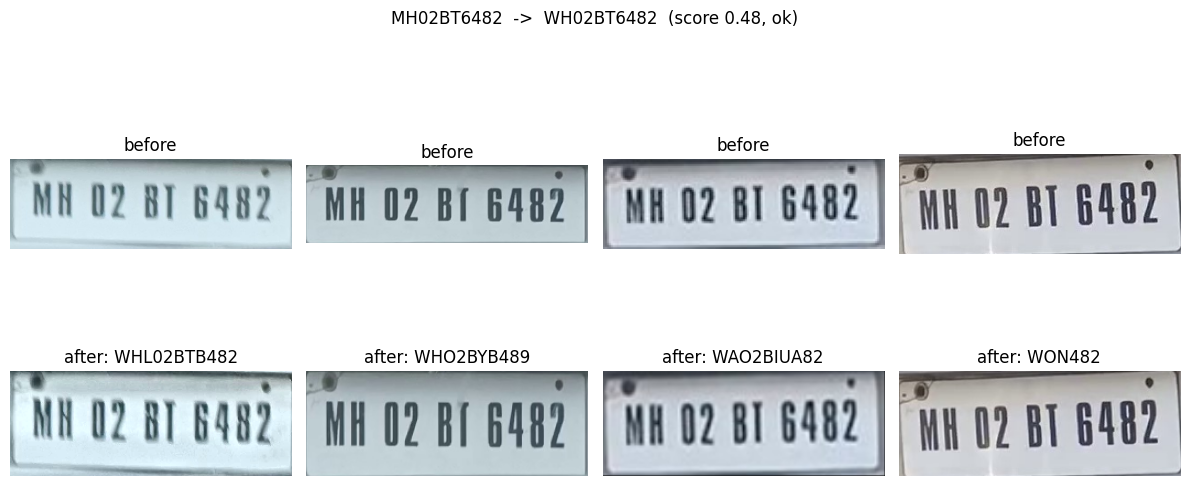

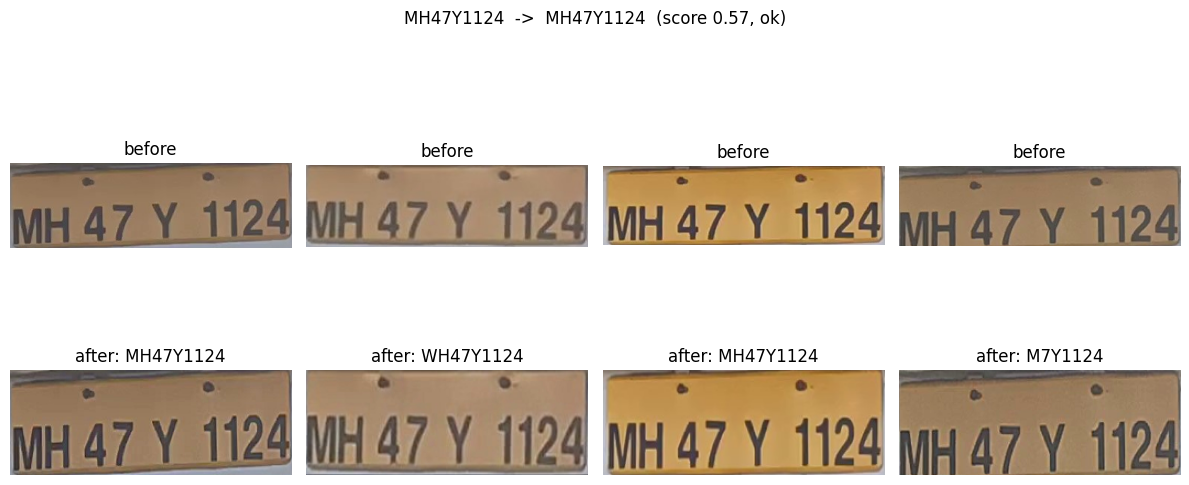

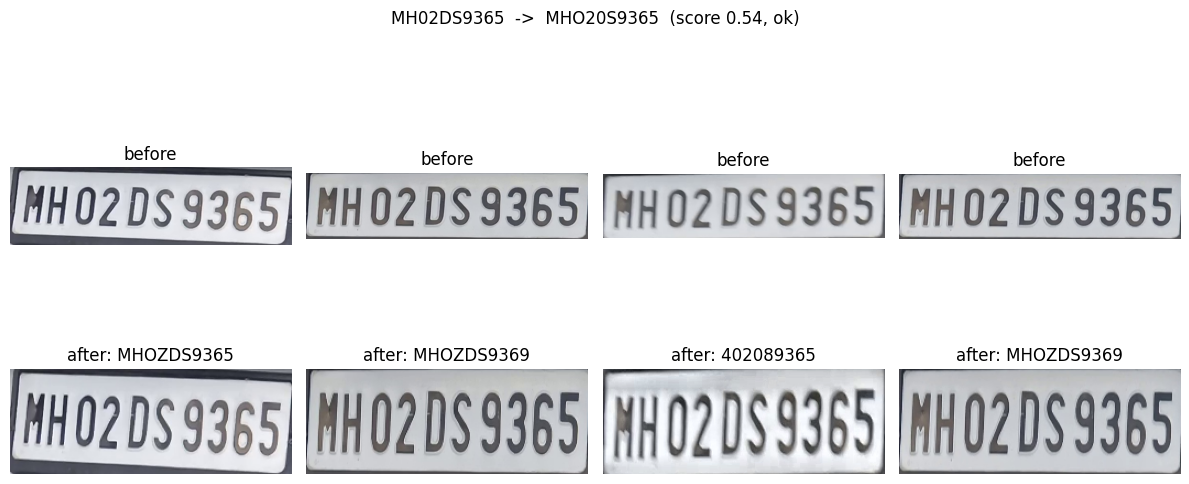

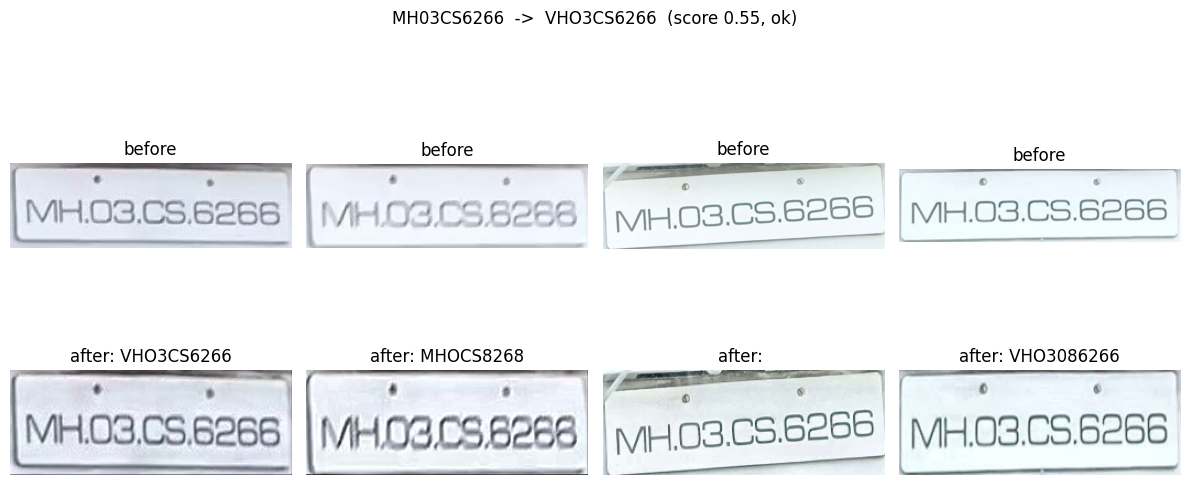

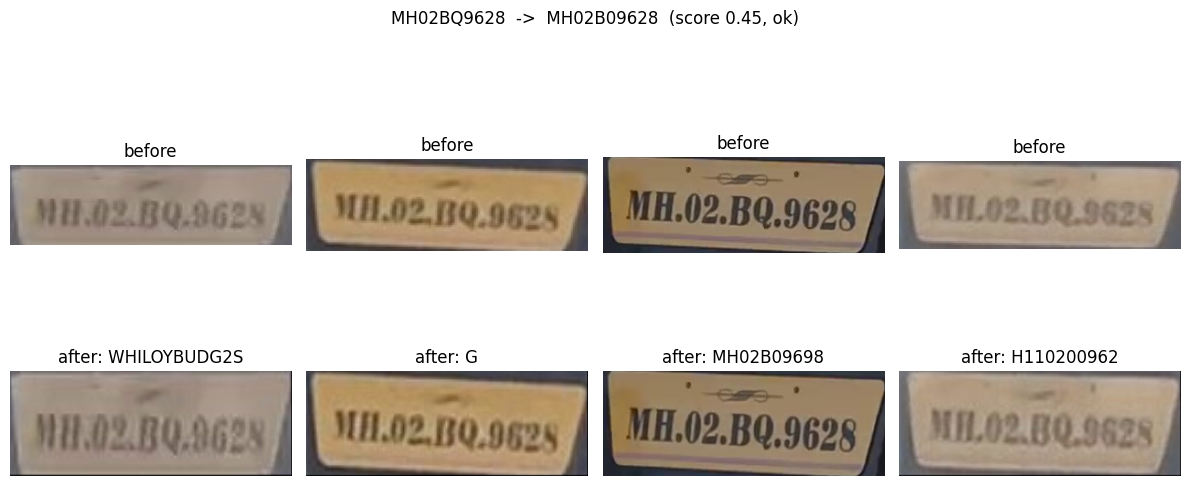

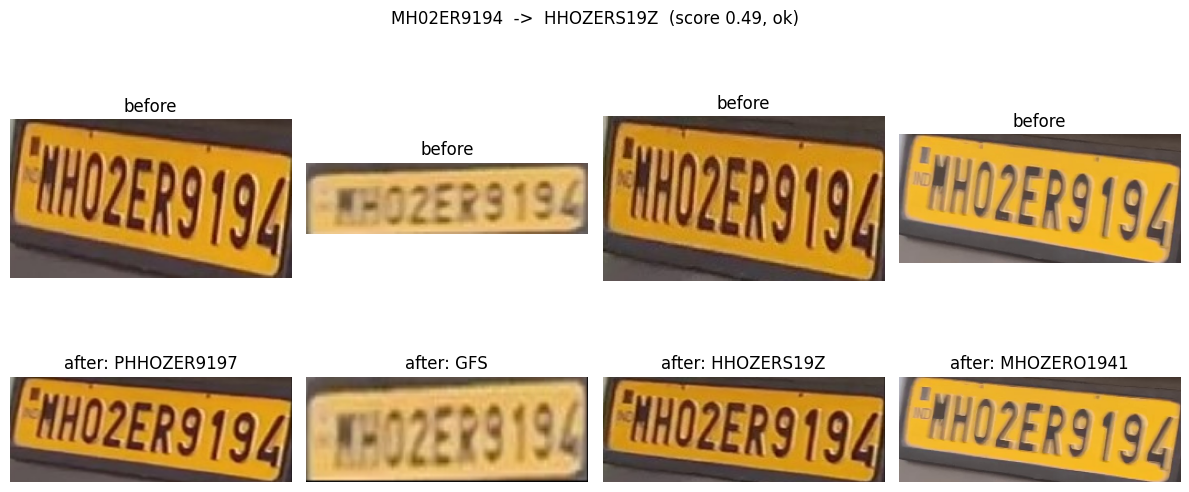

In [14]:
demo_plates = [t for t, c in counts.items() if c >= 2][:6]
if len(demo_plates) < 6:
    demo_plates += list(counts.index[:6 - len(demo_plates)])

for plate in demo_plates:
    records = df[df["plate_text"] == plate].to_dict("records")
    result = process_group(records)
    if result is None:
        continue
    shots = result["results"][:4]
    fig, axes = plt.subplots(2, len(shots), figsize=(3 * len(shots), 6))
    if len(shots) == 1:
        axes = axes.reshape(2, 1)
    for i, r in enumerate(shots):
        axes[0, i].imshow(cv2.cvtColor(r["crop"], cv2.COLOR_BGR2RGB)); axes[0, i].axis("off")
        axes[0, i].set_title("before")
        axes[1, i].imshow(cv2.cvtColor(r["cleaned"], cv2.COLOR_BGR2RGB)); axes[1, i].axis("off")
        axes[1, i].set_title(f"after: {r['text']}")
    fig.suptitle(f"{plate}  ->  {result['text']}  (score {result['score']:.2f}, {result['status']})")
    fig.tight_layout()
    fig.savefig(os.path.join(OUT_DIR, "samples", f"{plate}.png"), dpi=100)
    plt.show()
    plt.close(fig)

Check accuracy on the val plates the detector never trained on.

In [15]:
val_df = df[df["split"] == "val"].reset_index(drop=True)

single_rows = []
for _, row in val_df.iterrows():
    r = process_image(row["image_path"], (row["xmin"], row["ymin"], row["xmax"], row["ymax"]))
    if r is None:
        continue
    single_rows.append({"gt": row["plate_text"], "pred": r["text"],
                         "exact": r["text"] == row["plate_text"],
                         "char_acc": char_accuracy(r["text"], row["plate_text"]),
                         "cer": cer(r["text"], row["plate_text"])})
single_df = pd.DataFrame(single_rows)

fused_rows = []
for plate, records in val_groups.items():
    result = process_group(records)
    if result is None:
        continue
    pred = result["fused_text"]
    fused_rows.append({"gt": plate, "pred": pred, "exact": pred == plate,
                        "char_acc": char_accuracy(pred, plate), "cer": cer(pred, plate)})
fused_df = pd.DataFrame(fused_rows)

print("single photo OCR, n =", len(single_df))
print("  exact match:", round(single_df["exact"].mean(), 3))
print("  char accuracy:", round(single_df["char_acc"].mean(), 3))
print()
print("combined multi photo OCR, n =", len(fused_df))
print("  exact match:", round(fused_df["exact"].mean(), 3))
print("  char accuracy:", round(fused_df["char_acc"].mean(), 3))

single_df.to_csv(os.path.join(OUT_DIR, "single_photo_results.csv"), index=False)
fused_df.to_csv(os.path.join(OUT_DIR, "combined_results.csv"), index=False)

single photo OCR, n = 245
  exact match: 0.033
  char accuracy: 0.311

combined multi photo OCR, n = 36
  exact match: 0.056
  char accuracy: 0.427


In [16]:
# detector precision and recall on val images using iou against ground truth
det_precision = det_recall = None
if detector is not None:
    tp = fp = fn = 0
    for _, row in val_df.iterrows():
        bgr = cv2.imread(row["image_path"])
        if bgr is None:
            continue
        gt_box = (row["xmin"], row["ymin"], row["xmax"], row["ymax"])
        x1, y1, x2, y2, backend = detect_plate(bgr)
        if iou(gt_box, (x1, y1, x2, y2)) >= 0.5:
            tp += 1
        else:
            fp += 1; fn += 1
    det_precision = tp / (tp + fp) if (tp + fp) else 0.0
    det_recall = tp / (tp + fn) if (tp + fn) else 0.0
    print(f"detector precision={det_precision:.3f} recall={det_recall:.3f}")
else:
    print("no trained detector, skipping precision and recall")

detector precision=0.984 recall=0.984


Compare raw OCR, cleaned OCR, best single photo, and combined photos.

           method  char_accuracy
          raw_ocr       0.666667
      cleaned_ocr       0.554815
best_single_photo       0.253333
  combined_photos       0.360741


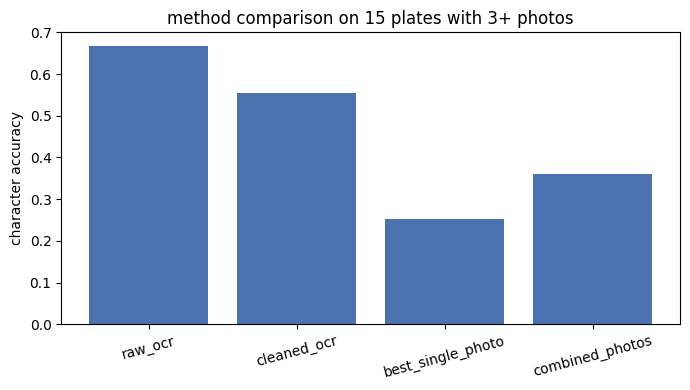

In [17]:
def raw_ocr(records):
    out = []
    for r in records:
        bgr = cv2.imread(r["image_path"])
        if bgr is None:
            continue
        crop = bgr[r["ymin"]:r["ymax"], r["xmin"]:r["xmax"]]
        text, conf = read_plate(crop)
        out.append({"text": text, "conf": conf, "weight": 1.0})
    return out

rows = []
for plate, records in val_groups_3plus.items():
    gt = plate
    raw = raw_ocr(records)
    raw_best = max((r["text"] for r in raw), key=lambda t: char_accuracy(t, gt), default="")

    cleaned = [process_image(r["image_path"], (r["xmin"], r["ymin"], r["xmax"], r["ymax"])) for r in records]
    cleaned = [c for c in cleaned if c is not None]
    cleaned_reads = [{"text": c["text"], "conf": c["conf"], "weight": c["weight"]} for c in cleaned]
    cleaned_best = max((r["text"] for r in cleaned_reads), key=lambda t: char_accuracy(t, gt), default="")

    best_single = max(cleaned_reads, key=lambda r: r["conf"], default={"text": ""})["text"]
    combined, _ = fuse_group(cleaned_reads) if cleaned_reads else ("", [])

    rows.append({
        "plate": gt,
        "raw_ocr": char_accuracy(raw_best, gt),
        "cleaned_ocr": char_accuracy(cleaned_best, gt),
        "best_single_photo": char_accuracy(best_single, gt),
        "combined_photos": char_accuracy(combined, gt),
    })

compare_df = pd.DataFrame(rows)
methods = ["raw_ocr", "cleaned_ocr", "best_single_photo", "combined_photos"]
summary_df = pd.DataFrame({"method": methods, "char_accuracy": [compare_df[m].mean() for m in methods]})
print(summary_df.to_string(index=False))
summary_df.to_csv(os.path.join(OUT_DIR, "method_comparison.csv"), index=False)

plt.figure(figsize=(7, 4))
plt.bar(summary_df["method"], summary_df["char_accuracy"], color="#4C72B0")
plt.ylabel("character accuracy")
plt.title(f"method comparison on {len(compare_df)} plates with 3+ photos")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "method_comparison.png"), dpi=100)
plt.show()

Save the trained detector and pipeline settings for later use.

In [18]:
config = {
    "plate_size": list(PLATE_SIZE),
    "quality_weights": WEIGHTS,
    "score_weights": {"ocr": 0.30, "agreement": 0.20, "stability": 0.20, "quality": 0.15, "geometry": 0.15},
    "char_threshold": 0.35,
    "score_threshold": 0.25,
    "detector_trained": detector is not None,
}
with open(os.path.join(MODEL_DIR, "pipeline_config.json"), "w") as f:
    json.dump(config, f, indent=2)

print("saved to", MODEL_DIR)
print(os.listdir(MODEL_DIR))

saved to /kaggle/working/models
['pipeline_config.json', 'plate_detector.pt']


Final performance for this run.

In [19]:
print("=" * 40)
print("FINAL PERFORMANCE")
print("=" * 40)
if det_precision is not None:
    print(f"detector precision:        {det_precision:.3f}")
    print(f"detector recall:           {det_recall:.3f}")
print(f"single photo exact match:  {single_df['exact'].mean():.3f}")
print(f"single photo char acc:     {single_df['char_acc'].mean():.3f}")
print(f"combined exact match:      {fused_df['exact'].mean():.3f}")
print(f"combined char acc:         {fused_df['char_acc'].mean():.3f}")
print("-" * 40)
print(summary_df.to_string(index=False))
print("=" * 40)

FINAL PERFORMANCE
detector precision:        0.984
detector recall:           0.984
single photo exact match:  0.033
single photo char acc:     0.311
combined exact match:      0.056
combined char acc:         0.427
----------------------------------------
           method  char_accuracy
          raw_ocr       0.666667
      cleaned_ocr       0.554815
best_single_photo       0.253333
  combined_photos       0.360741


Run this on any new photo, no ground truth needed.

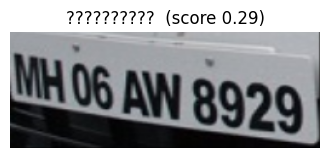

{'text': '??????????', 'score': 0.29007225555368277, 'status': 'ok'}


In [20]:
def recover(image_path):
    r = process_image(image_path)
    if r is None:
        return {"text": None, "status": "no plate found"}
    score = confidence_score(r["conf"], 0.0, r["conf"], r["quality"]["combined"], r["quality"]["perspective"])
    text, status = final_text(r["text"], [r["conf"]] * len(r["text"]), score)
    plt.figure(figsize=(4, 2))
    plt.imshow(cv2.cvtColor(r["cleaned"], cv2.COLOR_BGR2RGB))
    plt.title(f"{text}  (score {score:.2f})")
    plt.axis("off")
    plt.show()
    return {"text": text, "score": score, "status": status}


def recover_multi(image_paths):
    results = [process_image(p) for p in image_paths]
    results = [r for r in results if r is not None]
    if not results:
        return {"text": None, "status": "no plate found"}
    fused_text, char_conf = fuse_group([{"text": r["text"], "conf": r["conf"], "weight": r["weight"]} for r in results])
    agreement = float(np.mean([char_accuracy(r["text"], fused_text) for r in results]))
    score = confidence_score(float(np.mean([r["conf"] for r in results])), agreement,
                              float(np.mean(char_conf)) if char_conf else 0.0,
                              float(np.mean([r["quality"]["combined"] for r in results])),
                              float(np.mean([r["quality"]["perspective"] for r in results])))
    text, status = final_text(fused_text, char_conf, score)
    return {"text": text, "score": score, "status": status}

example = df.iloc[0]["image_path"]
print(recover(example))